# GNN testing walkthrough

Companion to `tests/gnn/` (the actual test suite) and `scripts/gnn_test_report.py`
(the diagnostics). This notebook does **not** redefine any tests — it runs the real
suite for the pass/fail verdict, then re-uses the report script's diagnostics to
show *what* the trained model does and how well, with plots.

Order:
1. run the pytest suite → verdict
2. data under test
3. headline AUC vs naive baselines
4. stability, calibration, feature importance, per-pair
5. the no-lookahead check, spelled out
6. seed robustness (optional, ~35 s per seed)


In [1]:
import os, sys, subprocess, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# locate project root (folder containing config.yaml) whether run from notebooks/ or root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
os.chdir(ROOT)                          # config.yaml paths (data/...) are root-relative
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
import gnn_test_report as gtr           # scripts/gnn_test_report.py
from src.common.config import load_config

cfg = load_config()
pd.set_option("display.width", 120)
print("project root:", ROOT)

project root: /Users/anany/Documents/Studie/Capstone/d2/Capstone


## 1. Run the real test suite

This is the source of truth. Everything below is illustration.

In [2]:
summary, tests = gtr.run_pytest()
print(summary)
status = pd.Series([s for s, _ in tests]).value_counts()
display(status.to_frame("count"))
failed = [t for s, t in tests if s in ("FAILED", "ERROR")]
assert not failed, f"failing tests: {failed}"
pd.DataFrame(tests, columns=["status", "test"])

58 passed, 1 skipped in 4.15s


,count


,status,test


## 2. Diagnostics on the trained checkpoint

One call computes everything the report shows (seeds off here; see the last section).

In [3]:
d = gtr.diagnostics(cfg, seeds=[])
data = d["data"]
pd.Series({
    "timeline": f'{data["days"]} days, {data["date_range"]}',
    "nodes / features": f'{data["nodes"]} / {data["features"]}',
    "curated edges / msg-passing edges / scored pairs": f'{data["edges_curated"]} / {data["edges_mp"]} / {data["pairs_scored"]}',
    "train samples": f'{data["n_train"]} ({data["train_pos"]:.1%} pos) {data["train_range"]}',
    "val samples": f'{data["n_val"]} ({data["val_pos"]:.1%} pos) {data["val_range"]}',
}).to_frame("value")

,value
timeline,"1174 days, 2021-10-01 -> 2026-06-30"
nodes / features,15 / 6
curated edges / msg-passing edges / scored pairs,32 / 64 / 64
train samples,2133 (17.8% pos) 2021-10-06 -> 2025-05-15
val samples,571 (22.6% pos) 2025-07-03 -> 2026-06-17


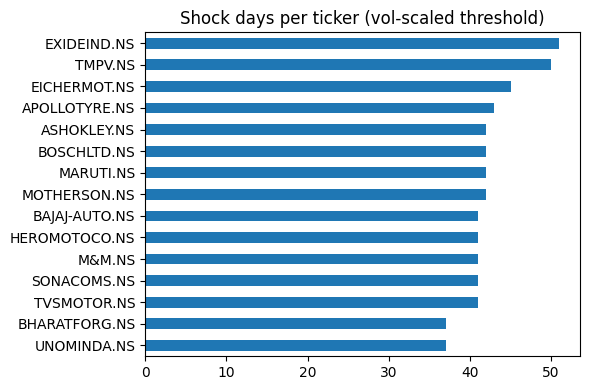

In [4]:
shocks = pd.Series(data["shock_days_per_ticker"])
shocks.plot.barh(figsize=(6, 4), title="Shock days per ticker (vol-scaled threshold)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## 3. Headline: GNN vs naive baselines on identical val samples

If the GNN can't beat a static return-correlation lookup or 'volatile stocks shock more', it learned nothing.

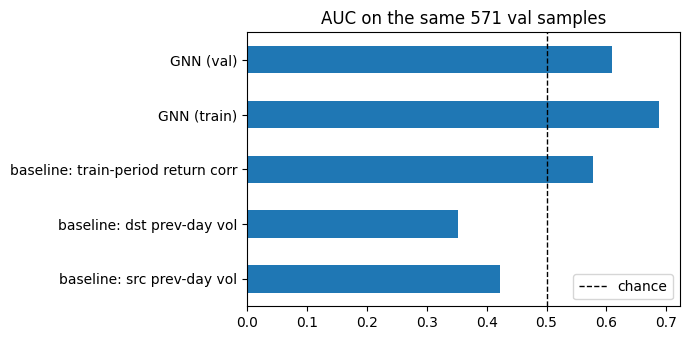

,AUC
GNN (val),0.6100
GNN (train),0.6885
baseline: train-period return corr,0.5784
baseline: dst prev-day vol,0.3523
baseline: src prev-day vol,0.4231


In [5]:
auc, base = d["auc"], d["baselines"]
scores = pd.Series({
    "GNN (val)": auc["val"],
    "GNN (train)": auc["train"],
    "baseline: train-period return corr": base["train_corr"],
    "baseline: dst prev-day vol": base["dst_prev_vol"],
    "baseline: src prev-day vol": base["src_prev_vol"],
})
ax = scores.plot.barh(figsize=(7, 3.5), title="AUC on the same 571 val samples")
ax.axvline(0.5, color="k", ls="--", lw=1, label="chance"); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()
scores.round(4).to_frame("AUC")

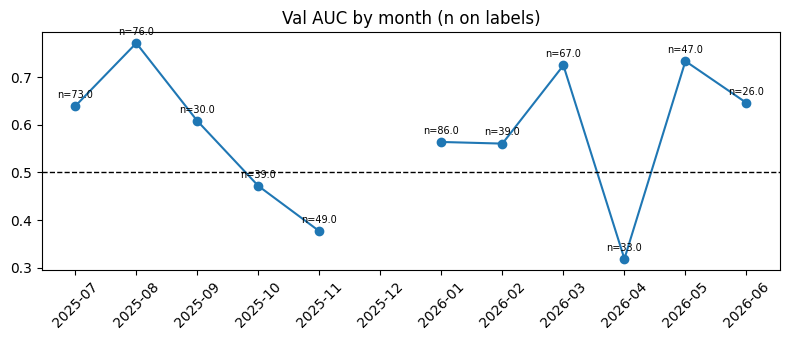

,n,pos,auc
month,,,
2025-07,73,15,0.639080
2025-08,76,18,0.771073
2025-09,30,5,0.608000
2025-10,39,8,0.471774
2025-11,49,10,0.376923
2025-12,6,0,NaN
2026-01,86,34,0.563914
2026-02,39,8,0.560484
2026-03,67,20,0.724468


In [6]:
monthly = pd.DataFrame(d["monthly"]).set_index("month")
fig, ax = plt.subplots(figsize=(8, 3.5))
xs = range(len(monthly))
ax.plot(xs, monthly["auc"], marker="o")
for i, (m, r) in enumerate(monthly.iterrows()):
    if r["auc"] == r["auc"]:
        ax.annotate(f'n={r["n"]}', (i, r["auc"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=7)
ax.set_xticks(list(xs)); ax.set_xticklabels(monthly.index, rotation=45)
ax.axhline(0.5, color="k", ls="--", lw=1); ax.set_title("Val AUC by month (n on labels)")
plt.tight_layout(); plt.show()
monthly

**Calibration** — does a higher score actually mean more cascades? (Absolute level is inflated by `pos_weight`; the *ordering* is what matters.)

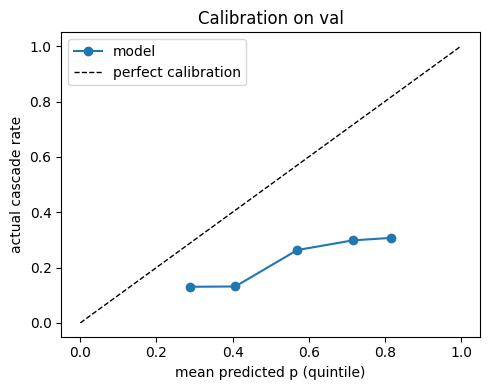

,bin,n,p_mean,actual
0,0,115,0.286954,0.130435
1,1,114,0.407188,0.131579
2,2,114,0.569817,0.263158
3,3,114,0.716073,0.298246
4,4,114,0.815906,0.307018


In [7]:
cal = pd.DataFrame(d["calibration"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(cal["p_mean"], cal["actual"], marker="o", label="model")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted p (quintile)"); ax.set_ylabel("actual cascade rate")
ax.set_title("Calibration on val"); ax.legend(); plt.tight_layout(); plt.show()
cal

**Feature permutation importance** — shuffle one input feature across days, measure the val-AUC drop.

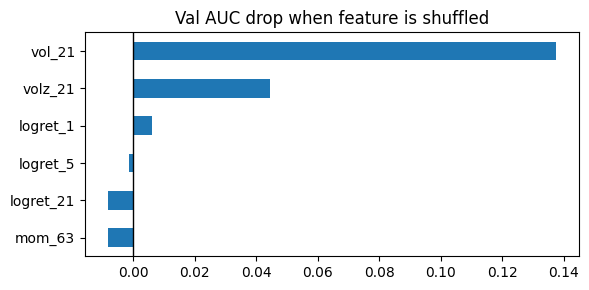

In [8]:
imp = pd.Series(d["feature_importance"])
imp.sort_values().plot.barh(figsize=(6, 3), title="Val AUC drop when feature is shuffled")
plt.axvline(0, color="k", lw=1); plt.tight_layout(); plt.show()

**Per-pair AUC** — which supply-chain edges does the model rank well / badly? (~9 val samples per pair: indicative only.)

In [9]:
pp = pd.DataFrame(d["per_pair"])
print(f"{len(pp)} evaluable pairs, {int((pp['auc'] < 0.5).sum())} below 0.5")
pd.concat({"top 5": pp.head(5), "bottom 5": pp.tail(5)})

36 evaluable pairs, 7 below 0.5


pair  n  pos       auc
top 5    0   BHARATFORG.NS->EICHERMOT.NS  9    2  1.000000
         1         BHARATFORG.NS->M&M.NS  9    2  1.000000
         2          EXIDEIND.NS->TMPV.NS  9    1  1.000000
         3     EXIDEIND.NS->EICHERMOT.NS  9    4  0.950000
         4        EXIDEIND.NS->MARUTI.NS  9    1  0.875000
bottom 5 31     BOSCHLTD.NS->ASHOKLEY.NS  9    2  0.357143
         32         BOSCHLTD.NS->TMPV.NS  9    2  0.357143
         33   HEROMOTOCO.NS->BOSCHLTD.NS  9    2  0.357143
         34    BOSCHLTD.NS->EICHERMOT.NS  9    2  0.285714
         35       BOSCHLTD.NS->MARUTI.NS  9    4  0.200000

## 5. The no-lookahead check, spelled out

The most important single test in the suite (`test_inference_has_no_lookahead`):
score day *t*, then overwrite **every day after t** with noise and score again.
If the output changes, the model is peeking into the future.

In [10]:
import torch
from src.common.seeding import set_global_seed
from src.models.gnn.graph_dataset import build_dataset, supervision_pairs, window_features
from src.models.gnn.model import PropagationGNN
from src.models.gnn.train import WEIGHTS_DIR

set_global_seed(cfg.project.seed)
gd = build_dataset(cfg)
model = PropagationGNN(in_dim=gd.x.shape[-1], cfg=cfg)
model.load_state_dict(torch.load(WEIGHTS_DIR / "propagation_gnn.pt", weights_only=True)); model.eval()
pos = {t: i for i, t in enumerate(gd.tickers)}
pairs = torch.tensor([[pos[u], pos[v]] for u, v in supervision_pairs(cfg)])
W, t = cfg.gnn.temporal_window_days, 300

x = gd.x.clone()
with torch.no_grad():
    before = model(window_features(x, t, W), gd.edge_index, pairs)
    x[t + 1:] = torch.randn_like(x[t + 1:]) * 10        # trash the future
    after_future = model(window_features(x, t, W), gd.edge_index, pairs)
    x = gd.x.clone(); x[t - 3] += 5.0                   # nudge a day INSIDE the window
    after_past = model(window_features(x, t, W), gd.edge_index, pairs)

print("day", gd.dates[t].date())
print("max |Δ| after corrupting the future :", float((before - after_future).abs().max()), "-> must be 0")
print("max |Δ| after nudging day t-3       :", float((before - after_past).abs().max()), "-> must be > 0 (window is used)")

day 2022-12-16
max |Δ| after corrupting the future : 0.0 -> must be 0
max |Δ| after nudging day t-3       : 0.13437247276306152 -> must be > 0 (window is used)


## 6. Seed robustness (optional)

Retrains with alternate seeds into a temp directory (shipped weights untouched).
Set `SEEDS = []` to skip. ~35 s per seed on CPU.

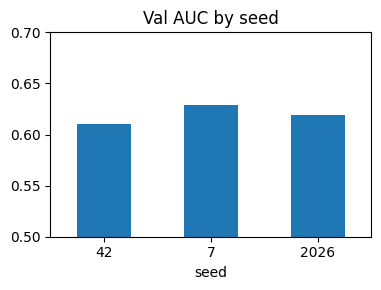

,val_auc,best_epoch,note,seconds
seed,,,,
42,0.6100,5,shipped,NaN
7,0.6291,15,retrained (temp dir),33.5
2026,0.6189,20,retrained (temp dir),37.4


In [11]:
SEEDS = [7, 2026]
if SEEDS:
    ds = gtr.diagnostics(cfg, seeds=SEEDS)
    meta = ds["meta"]
    rows = [{"seed": meta["seed"], "val_auc": meta["best_val_auc"], "best_epoch": meta["best_epoch"], "note": "shipped"}]
    rows += [{**r, "note": "retrained (temp dir)"} for r in ds["seeds"]]
    seeds_df = pd.DataFrame(rows).set_index("seed")
    seeds_df["val_auc"].plot.bar(figsize=(4, 3), title="Val AUC by seed", ylim=(0.5, 0.7), rot=0)
    plt.tight_layout(); plt.show()
    display(seeds_df)
else:
    print("skipped")

## Takeaways

- Suite verdict comes from pytest, not from this notebook.
- Signal is real but modest: ~0.61 val AUC vs 0.58 for a static correlation lookup.
- The model leans almost entirely on volatility features; return/momentum features are unused.
- Month-to-month AUC is unstable; the RL agent should not treat GNN scores as uniformly reliable.
- Inference is provably free of look-ahead and the cached scores reproduce bit-for-bit.

For the written report use `GNN_TEST_REPORT.md` (generated by `scripts/gnn_test_report.py`);
this notebook is the visual/appendix version of the same numbers.